# Bateria de 30 dias — MLP

Versão paralela do notebook oficial de 7 dias (em `horizonte_7dias/`),
**re-treinada do zero** para o horizonte de **30 dias**
(`contamination_level = 30`): rótulos, busca de hiperparâmetros (própria,
não reaproveitada de 7 dias), fit final no treino completo, limiar ótimo na
validação e métricas são todos recalculados. Mantém-se a janela oficial
`WINDOW = 90`, os mesmos splits por disco, o mesmo espaço de busca, o mesmo
`n_iter`/`cv` e `scoring='average_precision'` da bateria de 7 dias.

**Atenção (não comparar entre horizontes):** a prevalência de positivos em
30 dias (~8%) é cerca de 4× a de 7 dias (~2%), o que infla F1/AP
mecanicamente. Compare os modelos *dentro* do horizonte de 30 dias (e use
`AMA_comparacao_modelos_30d.ipynb`), não os números de 30d contra os de 7d.
Todas as saídas levam o sufixo `_30d`.

# Predicao de Falhas em SSDs - Multilayer Perceptron (MLP)

Este notebook treina um **Multilayer Perceptron (MLP)** para o mesmo problema
resolvido em `AMA_projeto_LSTM.ipynb`, `AMA_projeto_LogisticRegression.ipynb`
e `AMA_projeto_RandomForest.ipynb`: prever, para cada disco e cada dia, se ele
**vai falhar dentro dos proximos `CONTAMINATION_LEVEL` dias**.

Para garantir uma comparacao justa entre os quatro modelos do trabalho, este
notebook reaproveita - via o modulo `ssd_utils.py` - exatamente os mesmos
componentes usados nos notebooks de Regressao Logistica e Random Forest:

- **os mesmos indices de split** treino/teste/validacao do notebook do LSTM
  (`[0:3740]`, `[3740:4541]`, `[4541:]`);
- **a mesma funcao de rotulagem** `create_class_labels`, com
  `contamination_level = 30`;
- **as mesmas features de janela deslizante** (`build_windowed_features`),
  com `WINDOW = 90` - a janela escolhida no experimento de varredura
  (`AMA_experimento_janela.ipynb`);
- **as mesmas metricas de avaliacao**: acuracia, precisao, recall, F1-score e
  matriz de confusao, calculadas apenas sobre os timesteps validos
  (`mask == 1`).

### Por que MLP?

O artigo organiza os modelos em dois eixos: linear x nao-linear, e tabular
(vetor fixo) x sequencial (memoria temporal). O LSTM e nao-linear e
sequencial; a Regressao Logistica e linear e tabular; o Random Forest e
nao-linear e tabular. O **MLP completa o quadro**: e nao-linear como o RF,
mas tabular como a LR - recebe exatamente o mesmo vetor de 120 features por
amostra `(disco, dia)`, sem nenhuma nocao de sequencia.

Isso permite isolar dois efeitos na comparacao final:

- **LR -> MLP** isola o ganho de **nao-linearidade**, mantendo a
  representacao (tabular) fixa;
- **MLP -> LSTM** isola o ganho de **modelagem sequencial**, mantendo a
  capacidade nao-linear.

Expectativa: o MLP deve ficar entre a Regressao Logistica e o Random Forest
(ou proximo do Random Forest), e bem abaixo do LSTM.

### Resultados

Ao final, o notebook salva `resultados_mlp_30d.pkl` no mesmo formato dos demais
modelos tabulares, para que `AMA_comparacao_modelos.ipynb` possa incluir o
MLP nas tabelas e graficos comparativos.


In [1]:
# ===== Configuracao =====
import os
import time
import pickle

import numpy as np

import os
import sys

# --- Resolucao robusta de caminhos (independente do diretorio de trabalho) ---
def _encontra_raiz(inicio=None):
    """Sobe na arvore ate achar comum/ssd_utils.py."""
    d = os.path.abspath(inicio or os.getcwd())
    while True:
        if os.path.isfile(os.path.join(d, 'comum', 'ssd_utils.py')):
            return d
        pai = os.path.dirname(d)
        if pai == d:
            raise RuntimeError('raiz do projeto (com comum/ssd_utils.py) nao encontrada')
        d = pai

PROJ_ROOT = _encontra_raiz()
COMUM_DIR = os.path.join(PROJ_ROOT, 'comum')
H7_DIR = os.path.join(PROJ_ROOT, 'horizonte_7dias')
H30_DIR = os.path.join(PROJ_ROOT, 'horizonte_30dias')
EXP_DIR = os.path.join(PROJ_ROOT, 'experimentos')
if COMUM_DIR not in sys.path:
    sys.path.insert(0, COMUM_DIR)
# ---------------------------------------------------------------------------
import ssd_utils as ssd

DATA_DIR = COMUM_DIR        # data.pickle / mask.pickle (pasta comum/)
OUTPUT_DIR = H30_DIR        # resultados, modelos e figuras (bateria de 30 dias)
WINDOW = 90                  # janela oficial escolhida no experimento (AMA_experimento_janela.ipynb)
CONTAMINATION_LEVEL = 30     # horizonte de previsao de falha - igual ao notebook do LSTM
RANDOM_STATE = 42


## 1. Carregamento dos dados, rotulos e construcao das features

Identico ao notebook de Regressao Logistica e ao de Random Forest - ver
aqueles notebooks para uma explicacao detalhada de `create_class_labels` e
`build_windowed_features`. Repetimos aqui para que este notebook seja
executavel de forma independente.


In [2]:
data, mask = ssd.load_dataset(DATA_DIR)
print(f'data: {data.shape}   mask: {mask.shape}')

labels = ssd.create_class_labels(data, mask, CONTAMINATION_LEVEL)
print(f'labels: {labels.shape}   positivos: {int(labels.sum())} '
      f'({labels.mean()*100:.3f}% dos timesteps - desbalanceamento extremo)')

start = time.time()
X_all, disco_id, timestep, feature_cols = ssd.build_windowed_features(data, mask, window=WINDOW)
print(f'X_all: {X_all.shape}   ({len(feature_cols)} features por amostra)')
print(f'Tempo de construcao das features: {time.time() - start:.1f}s')


data: (5343, 360, 24)   mask: (5343, 360)
labels: (5343, 360)   positivos: 158845 (8.258% dos timesteps - desbalanceamento extremo)


X_all: (1923480, 120)   (120 features por amostra)
Tempo de construcao das features: 21.6s


## 2. Divisao treino / teste / validacao

Mesmos indices de disco do notebook do LSTM, da Regressao Logistica e do
Random Forest. Descartamos o padding (`mask == 0`), assim como o
`batch_evaluation` do LSTM ignora essas posicoes ao calcular metricas e
perda.


In [3]:
splits_idx = ssd.split_indices(n_discos=data.shape[0])
y_flat = labels.reshape(-1)
mask_flat = mask.reshape(-1)

train = ssd.select_split(X_all, disco_id, timestep, y_flat, mask_flat, splits_idx['train'])
test = ssd.select_split(X_all, disco_id, timestep, y_flat, mask_flat, splits_idx['test'])
validation = ssd.select_split(X_all, disco_id, timestep, y_flat, mask_flat, splits_idx['validation'])

for nome, split in [('treino', train), ('teste', test), ('validacao', validation)]:
    n = len(split['y'])
    n_pos = int(split['y'].sum())
    print(f'{nome:10s}: {n:>9,} amostras validas | positivas: {n_pos:>6,} ({n_pos/n*100:.3f}%)')


treino    : 1,240,487 amostras validas | positivas: 111,132 (8.959%)
teste     :   265,245 amostras validas | positivas: 23,845 (8.990%)
validacao :   267,254 amostras validas | positivas: 23,868 (8.931%)


## 3. Padronizacao das features

Assim como a Regressao Logistica, o MLP e sensivel a escala das variaveis
(o gradiente do treino por backpropagation converge muito mal com features em
escalas muito diferentes). O `StandardScaler` e ajustado **apenas no conjunto
de treino** (para nao vazar estatisticas de teste/validacao) e depois aplicado
aos tres conjuntos.


In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(train['X'])
X_test = scaler.transform(test['X'])
X_validation = scaler.transform(validation['X'])

y_train, y_test, y_validation = train['y'], test['y'], validation['y']


## 4. Modelo e desbalanceamento de classes

O `MLPClassifier` do scikit-learn, diferente da Regressao Logistica e do
Random Forest, **nao possui o parametro `class_weight`** - nao ha como pesar
a classe positiva diretamente durante o treino.

A estrategia adotada, consistente com o restante do projeto, e treinar com a
distribuicao original de classes (~0,3-2% positivos) e ajustar o ponto de
operacao depois, escolhendo o limiar que maximiza o F1-score na validacao
(`ssd.best_threshold_f1`) - exatamente como ja e feito para LR e RF.

A comparacao principal entre os quatro modelos usa AUC-ROC e Average
Precision (AP), metricas de ranking que dependem apenas das probabilidades
preditas, nao do limiar de classificacao. Como essas metricas sao
independentes do limiar, a ausencia de `class_weight` no MLP nao compromete a
comparabilidade entre os modelos.


## 5. Busca de hiperparametros

Treinar um `MLPClassifier` com `RandomizedSearchCV` (varios fits de
treino + validacao interna) sobre o conjunto de treino completo (~1,2 milhao
de linhas x 120 features) seria caro demais. Por isso, a busca e feita numa
**subamostra estratificada de ate ~300 mil linhas do treino**
(`train_test_split` com `stratify=y_train` e `random_state=RANDOM_STATE`,
preservando a proporcao de positivos), e o **ajuste final e feito no conjunto
de treino completo**, com os melhores hiperparametros encontrados.

Espaco de busca: numero e tamanho das camadas ocultas
(`hidden_layer_sizes`), regularizacao L2 (`alpha`) e taxa de aprendizado
inicial (`learning_rate_init`). `early_stopping=True` reserva 10% dos dados
de treino (da subamostra, na busca; do treino completo, no ajuste final) para
validacao interna e encerra o treino quando essa perda parar de melhorar -
util para nao gastar epochs desnecessarias.

A busca otimiza **Average Precision** (`scoring='average_precision'`), e
nao F1: a comparacao entre os modelos do trabalho e feita por AP (metrica
de ranking, independente de limiar) e o ponto de operacao e escolhido
depois, na validacao. Selecionar hiperparametros pelo mesmo criterio evita
o vies do corte fixo de 0,5 embutido no F1 do `scoring='f1'`.


In [5]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RandomizedSearchCV, train_test_split

SUBSAMPLE_SIZE = min(300_000, len(X_train) - 2)

X_search, _, y_search, _ = train_test_split(
    X_train, y_train,
    train_size=SUBSAMPLE_SIZE,
    stratify=y_train,
    random_state=RANDOM_STATE,
)
print(f'Subamostra para busca: {X_search.shape[0]:,} amostras '
      f'({y_search.mean()*100:.3f}% positivas, vs {y_train.mean()*100:.3f}% no treino completo)')

param_distributions = {
    'hidden_layer_sizes': [(64,), (128,), (64, 32), (128, 64)],
    'alpha': [1e-4, 1e-3, 1e-2],            # regularizacao L2
    'learning_rate_init': [1e-3, 1e-4],
}
base_mlp = MLPClassifier(
    activation='relu', solver='adam', batch_size=512,
    max_iter=100, early_stopping=True, n_iter_no_change=10,
    validation_fraction=0.1, random_state=RANDOM_STATE,
)
search = RandomizedSearchCV(
    base_mlp, param_distributions, n_iter=8, scoring='average_precision',
    cv=3, random_state=RANDOM_STATE, n_jobs=-1, verbose=2,
)

start = time.time()
search.fit(X_search, y_search)
search_time = time.time() - start

print(f'Melhores hiperparametros: {search.best_params_}')
print(f'AP medio (CV) do melhor modelo: {search.best_score_:.4f}')
print(f'Tempo da busca: {search_time/60:.1f} min')


Subamostra para busca: 300,000 amostras (8.959% positivas, vs 8.959% no treino completo)
Fitting 3 folds for each of 8 candidates, totalling 24 fits


Melhores hiperparametros: {'learning_rate_init': 0.001, 'hidden_layer_sizes': (128,), 'alpha': 0.01}
AP medio (CV) do melhor modelo: 0.3698
Tempo da busca: 8.8 min


## 6. Treino do modelo final

Re-treina o `MLPClassifier` com os melhores hiperparametros encontrados,
agora sobre todo o conjunto de treino, medindo o tempo de treino isoladamente
(util para comparar custo computacional entre os quatro modelos no artigo).


In [6]:
best_mlp = MLPClassifier(
    **search.best_params_,
    activation='relu', solver='adam', batch_size=512,
    max_iter=100, early_stopping=True, n_iter_no_change=10,
    validation_fraction=0.1, random_state=RANDOM_STATE,
)

start = time.time()
best_mlp.fit(X_train, y_train)
train_time = time.time() - start
print(f'Tempo de treino do modelo final: {train_time/60:.1f} min')
print(f'Convergiu em {best_mlp.n_iter_} iteracoes (max_iter=100)')


Tempo de treino do modelo final: 56.7 min
Convergiu em 98 iteracoes (max_iter=100)


## 7. Avaliacao

Mesmas metricas usadas no LSTM, na Regressao Logistica e no Random Forest -
acuracia, precisao, recall, F1-score e matriz de confusao - calculadas em
teste e validacao. O limiar de classificacao e escolhido na validacao
(maximizando F1) e aplicado tambem ao teste.


In [7]:
test_proba = best_mlp.predict_proba(X_test)[:, 1]
val_proba  = best_mlp.predict_proba(X_validation)[:, 1]

thr = ssd.best_threshold_f1(y_validation, val_proba)   # escolhido na validacao
print(f'Limiar otimo (F1): {thr:.4f}')

test_pred = (test_proba >= thr).astype(int)
val_pred  = (val_proba  >= thr).astype(int)

test_metrics = ssd.evaluate_predictions(y_test, test_pred)
val_metrics  = ssd.evaluate_predictions(y_validation, val_pred)
ssd.print_metrics('teste', test_metrics); print()
ssd.print_metrics('validacao', val_metrics)


Limiar otimo (F1): 0.2441


--- TESTE ---
Accuracy:  0.8587
Precision: 0.2650
Recall:    0.3227
F1-score:  0.2910
Matriz de confusão ([[TN, FP], [FN, TP]]):
[[220060  21340]
 [ 16151   7694]]

--- VALIDACAO ---
Accuracy:  0.8590
Precision: 0.2715
Recall:    0.3441
F1-score:  0.3036
Matriz de confusão ([[TN, FP], [FN, TP]]):
[[221349  22037]
 [ 15654   8214]]


## 8. Salvando resultados para comparacao posterior

Mesmo formato de `resultados_logistic_regression.pkl` e
`resultados_random_forest.pkl` (sem a chave `feature_importances`, que nao
tem equivalente direto para o MLP), para que `AMA_comparacao_modelos.ipynb`
possa incluir o MLP nas tabelas e graficos comparativos junto com os demais
modelos.


In [8]:
results = {
    'model_name': 'MLP',
    'contamination_level': CONTAMINATION_LEVEL,
    'window': WINDOW,
    'feature_cols': feature_cols,
    'best_params': search.best_params_,
    'cv_best_ap': search.best_score_,
    'search_time_seconds': search_time,
    'train_time_seconds': train_time,
    'threshold': thr,
    'metrics': {'test': test_metrics, 'validation': val_metrics},
    'predictions': {
        'test': {
            'disco_id': test['disco_id'], 'timestep': test['timestep'],
            'y_true': y_test, 'y_pred': test_pred, 'y_proba': test_proba,
        },
        'validation': {
            'disco_id': validation['disco_id'], 'timestep': validation['timestep'],
            'y_true': y_validation, 'y_pred': val_pred, 'y_proba': val_proba,
        },
    },
}

ssd.save_results(os.path.join(OUTPUT_DIR, 'resultados_mlp_30d.pkl'), **results)

with open(os.path.join(OUTPUT_DIR, 'modelo_mlp_30d.pkl'), 'wb') as f:
    pickle.dump({'model': best_mlp, 'scaler': scaler}, f)
print('Modelo + scaler salvos em modelo_mlp_30d.pkl')


Resultados salvos em: C:\Users\len108\Documents\pv\ErroSSD\horizonte_30dias\resultados_mlp_30d.pkl
Modelo + scaler salvos em modelo_mlp_30d.pkl


## Curva de aprendizagem

Desempenho (**Average Precision**) em funcao do tamanho do conjunto de treino.
Para cada fracao (de 2% ate **100%** do treino) o modelo e re-treinado e avaliado
no **mesmo split de validacao do projeto** (o split por disco usado no numero
final) - entao o **ultimo ponto coincide com o AP do modelo final** mostrado em
`AMA_comparacao_modelos`. A linha tracejada e o AP medido no proprio treino
(diagnostico de overfitting); a linha cheia e a validacao. E um diagnostico extra
e **nao** altera o modelo salvo nem os resultados.

> Re-treina o modelo em fracoes crescentes (incl. 100% = treino completo), entao
> custa ~2x um treino. Para acelerar, reduza a lista `fracs`. Os hiperparametros
> sao os ja escolhidos na busca (lidos da memoria ou do `.pkl` de resultados).

Curva de aprendizagem (avaliando na validacao do projeto):


  treino=   24,809  AP_treino=0.2342  AP_val=0.2164


  treino=   62,024  AP_treino=0.3134  AP_val=0.2691


  treino=  124,048  AP_treino=0.3696  AP_val=0.2744


C:\Users\len108\Documents\pv\ErroSSD\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


  treino=  310,121  AP_treino=0.4807  AP_val=0.2359


  treino=  620,243  AP_treino=0.4918  AP_val=0.2526


  treino=1,240,487  AP_treino=0.5328  AP_val=0.2407


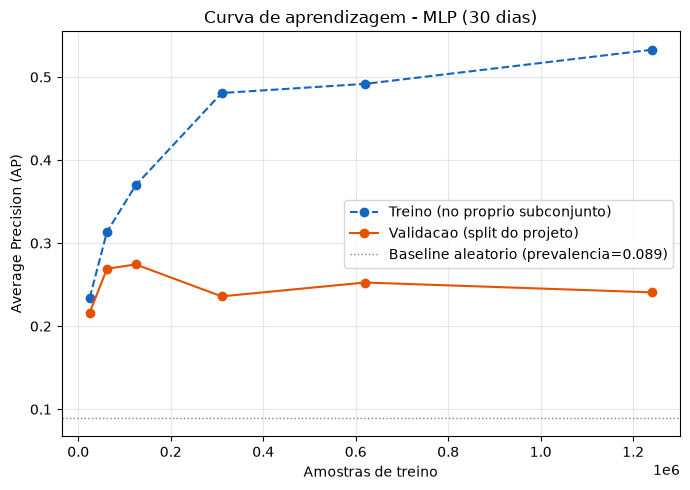

Curva de aprendizagem salva em mlp_learning_curve_30d.png  (ultimo ponto = AP do modelo final na validacao)
Dados da curva salvos em mlp_learning_curve_30d.pkl


In [9]:
# Curva de aprendizagem FIEL: AP x tamanho do treino, avaliando no split de validacao do projeto.
import os, pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.metrics import average_precision_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# hiperparametros: usa os da busca (se na memoria) ou le do .pkl de resultados
try:
    _bp = dict(search.best_params_)
except NameError:
    with open(os.path.join(OUTPUT_DIR, 'resultados_mlp_30d.pkl'), 'rb') as _f:
        _bp = pickle.load(_f)['best_params']

base_est = make_pipeline(
    StandardScaler(),
    MLPClassifier(**_bp, activation='relu', solver='adam', batch_size=512,
                  max_iter=100, early_stopping=True, n_iter_no_change=10,
                  validation_fraction=0.1, random_state=RANDOM_STATE))

Xtr_full, ytr_full = train['X'], train['y']     # treino completo (sem escalonar; pipeline cuida disso)
Xval, yval = validation['X'], validation['y']   # split de validacao do projeto (mesmo do numero final)

fracs = [0.02, 0.05, 0.1, 0.25, 0.5, 1.0]
sizes, ap_tr, ap_va = [], [], []
print('Curva de aprendizagem (avaliando na validacao do projeto):')
for fr in fracs:
    if fr < 1.0:
        X_s, _, y_s, _ = train_test_split(Xtr_full, ytr_full, train_size=fr,
                                          stratify=ytr_full, random_state=RANDOM_STATE)
    else:
        X_s, y_s = Xtr_full, ytr_full
    est = clone(base_est)
    est.fit(X_s, y_s)
    ap_v = average_precision_score(yval, est.predict_proba(Xval)[:, 1])
    ap_t = average_precision_score(y_s, est.predict_proba(X_s)[:, 1])
    sizes.append(len(y_s)); ap_va.append(ap_v); ap_tr.append(ap_t)
    print(f'  treino={len(y_s):>9,}  AP_treino={ap_t:.4f}  AP_val={ap_v:.4f}')

sizes = np.array(sizes); ap_tr = np.array(ap_tr); ap_va = np.array(ap_va)
_prev = float(np.mean(yval))

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(sizes, ap_tr, 'o--', color='#1565C0', label='Treino (no proprio subconjunto)')
ax.plot(sizes, ap_va, 'o-', color='#E65100', label='Validacao (split do projeto)')
ax.axhline(_prev, color='gray', ls=':', lw=1, label=f'Baseline aleatorio (prevalencia={_prev:.3f})')
ax.set_xlabel('Amostras de treino')
ax.set_ylabel('Average Precision (AP)')
ax.set_title('Curva de aprendizagem - MLP (30 dias)')
ax.legend(loc='best')
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'mlp_learning_curve_30d.png'), dpi=130, bbox_inches='tight')
plt.show()
print('Curva de aprendizagem salva em mlp_learning_curve_30d.png  (ultimo ponto = AP do modelo final na validacao)')

# Salva os dados para a figura consolidada da comparacao (std=0: estimativa unica por ponto)
with open(os.path.join(OUTPUT_DIR, 'mlp_learning_curve_30d.pkl'), 'wb') as _f:
    pickle.dump({'model_name': 'MLP', 'scoring': 'average_precision',
                 'train_sizes': sizes,
                 'train_mean': ap_tr, 'train_std': np.zeros_like(ap_tr),
                 'val_mean': ap_va, 'val_std': np.zeros_like(ap_va)}, _f)
print('Dados da curva salvos em mlp_learning_curve_30d.pkl')


## Curva de perda do MLP

Perda de treino por iteracao (epoch) do MLP final; havendo *early stopping*,
tambem o score de validacao interna. Mostra a convergencia do treino.

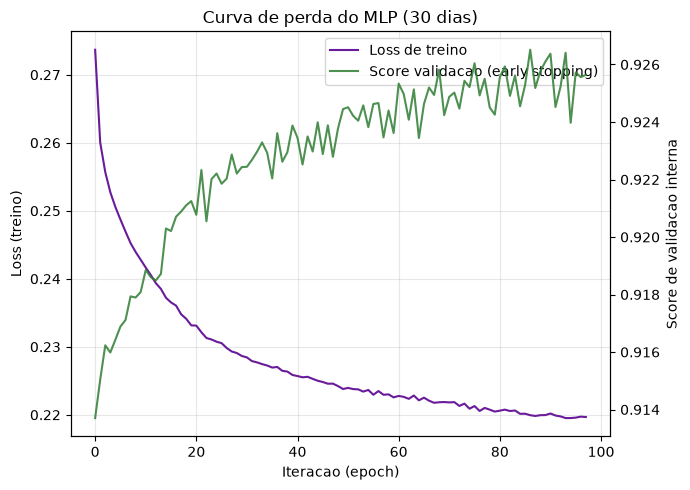

Curva de perda do MLP salva em mlp_loss_curve_30d.png


In [10]:
# Curva de perda do MLP final: loss de treino por iteracao (+ score de validacao interna)
import os
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(best_mlp.loss_curve_, color='#6A1B9A', label='Loss de treino')
ax.set_xlabel('Iteracao (epoch)')
ax.set_ylabel('Loss (treino)')
ax.set_title('Curva de perda do MLP (30 dias)')
if getattr(best_mlp, 'validation_scores_', None) is not None:
    ax2 = ax.twinx()
    ax2.plot(best_mlp.validation_scores_, color='#2E7D32', alpha=0.85,
             label='Score validacao (early stopping)')
    ax2.set_ylabel('Score de validacao interna')
    linhas = ax.get_lines() + ax2.get_lines()
    ax.legend(linhas, [l.get_label() for l in linhas], loc='best')
else:
    ax.legend(loc='best')
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'mlp_loss_curve_30d.png'), dpi=130, bbox_inches='tight')
plt.show()
print('Curva de perda do MLP salva em mlp_loss_curve_30d.png')
